In [199]:
# Loading the data

import pandas as pd
import numpy as np

# Load returns matrix
df_returns = pd.read_csv("matrix_returns.csv")

# Load company names
with open("company_names.csv", "r") as f:
    company_names = [line.strip() for line in f]

# Remove the first entry if it is the header
company_names = company_names[1:]

# Verify
print(df_returns.shape)
print(company_names[:50])
print(len(company_names))

(50, 5281)
['"NVDA"', '"AAPL"', '"MSFT"', '"AMZN"', '"GOOGL"', '"GOOG"', '"WMT"', '"BRK-B"', '"JPM"', '"LLY"', '"XOM"', '"AMD"', '"MU"', '"JNJ"', '"ORCL"', '"COST"', '"INTC"', '"NFLX"', '"CAT"', '"BAC"', '"CVX"', '"CSCO"', '"PG"', '"HD"', '"LRCX"', '"AMAT"', '"KO"', '"UNH"', '"MS"', '"GE"', '"MRK"', '"GS"', '"KLAC"', '"TXN"', '"WFC"', '"LIN"', '"RTX"', '"C"', '"IBM"', '"AXP"', '"MCD"', '"PEP"', '"NEE"', '"ADI"', '"VZ"', '"AMGN"', '"APH"', '"T"', '"BA"', '"DIS"']
50


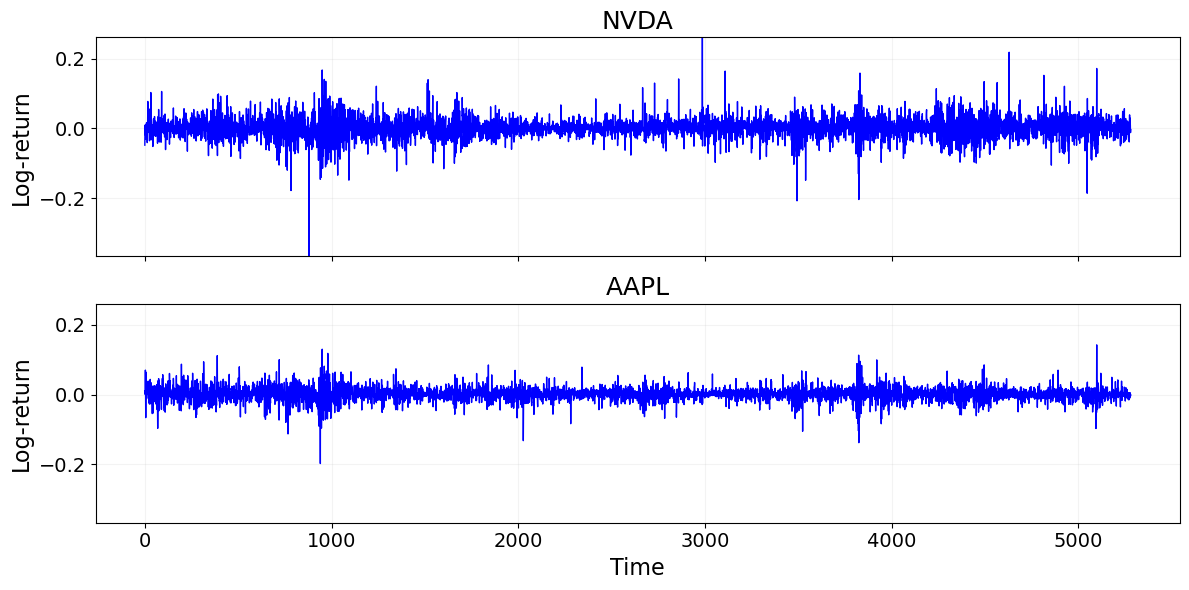

In [200]:
# Plotting the time series of NVDA and AAPL

import matplotlib.pyplot as plt

# Same y-axis scale for both series
ymin = min(df_returns.iloc[0].min(), df_returns.iloc[1].min())
ymax = max(df_returns.iloc[0].max(), df_returns.iloc[1].max())

plt.style.use("default")

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, sharey=True, facecolor="white"
)

fig.patch.set_facecolor("white")
ax1.set_facecolor("white")
ax2.set_facecolor("white")

# NVDA
ax1.plot(df_returns.iloc[0].values, color="blue", lw=1)
ax1.set_title("NVDA", fontsize=18)
ax1.set_ylabel("Log-return", fontsize=16)
ax1.set_ylim(ymin, ymax)
ax1.grid(True, alpha=0.15)

# AAPL
ax2.plot(df_returns.iloc[1].values, color="blue", lw=1)
ax2.set_title("AAPL", fontsize=18)
ax2.set_ylabel("Log-return", fontsize=16)
ax2.set_xlabel("Time", fontsize=16)
ax2.set_ylim(ymin, ymax)
ax2.grid(True, alpha=0.15)

# Tick labels and spines
for ax in (ax1, ax2):
    ax.tick_params(axis="both", labelsize=14, colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")

plt.tight_layout()
plt.savefig("nvda_aapl_white_bigfonts.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [51]:
# !pip install scikit-learn-extra
# !pip install "numpy<2.0"
# !pip install arch
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [52]:
import numpy as np
from arch import arch_model

def is_strictly_stationary(alpha, beta, nu, num_samples=50000):
    rng = np.random.default_rng()
    eps = rng.standard_t(df=nu, size=num_samples)
    
    # Standardize to variance 1
    eps = eps/np.sqrt(nu / (nu - 2))
    
    vals = np.log(alpha * eps**2 + beta)
    return np.mean(vals) < 0

def compute_qaf(ts, tau_1 = 0.5, tau_2 = 0.5, lag = 1):
    ts = np.asarray(ts)
    l_ts = len(ts)

    ts_1 = ts[:l_ts - lag]
    ts_2 = ts[lag:]

    q_tau_1 = np.quantile(ts, tau_1)
    q_tau_2 = np.quantile(ts, tau_2)

    indicators_1 = (ts_1 <= q_tau_1).astype(float)
    indicators_2 = (ts_2 <= q_tau_2).astype(float)

    numerator = (1/l_ts) * np.sum(indicators_1 * indicators_2) - tau_1 * tau_2
    denominator = np.sqrt(tau_1 * (1 - tau_1) * tau_2 * (1 - tau_2))

    return numerator/denominator

def compute_qafs(ts, levels, lags):
    levels = np.asarray(levels)
    lags = np.asarray(lags)

    l_levels = len(levels)
    l_lags = len(lags)
    array_features = np.zeros((l_levels, l_levels, l_lags))

    for i in range(l_levels):
        for j in range(l_levels):
            for k in range(l_lags):
                array_features[i, j, k] = compute_qaf(
                    ts,
                    tau_1=levels[i],
                    tau_2=levels[j],
                    lag=lags[k]
                )

    return array_features.ravel(order="F")

def sample_crp_with_min_clusters(alpha, n):
    """Generate cluster assignments for n items from a CRP with concentration alpha,
    conditioned on having more than 1 cluster."""
    while True:
        assignments = []
        cluster_counts = []
        for i in range(n):
            if i == 0:
                assignments.append(0)
                cluster_counts.append(1)
            else:
                probs = np.array(cluster_counts + [alpha])
                probs = probs / probs.sum()
                choice = np.random.choice(len(probs), p=probs)
                assignments.append(choice)
                if choice == len(cluster_counts):
                    cluster_counts.append(1)
                else:
                    cluster_counts[choice] += 1
        
        assignments = np.array(assignments)
        if len(np.unique(assignments)) > 1:
            return assignments
        # else repeat the simulation until more than one cluster is produced

def simulate_garch11_clustering_with_qaf(series_length, nu_choices, random_state=None):
    rng = np.random.default_rng(random_state)

    n = 50
    alpha1 = rng.exponential(0.5)
    cluster_assignments = sample_crp_with_min_clusters(alpha1, n)

    unique_clusters = np.unique(cluster_assignments)
    K = len(unique_clusters)

    cluster_garch_params = []
    for _ in range(K):
        omega = rng.uniform(1e-6, 1e-4)
        alpha = rng.uniform(0.01, 0.30)
        beta = rng.uniform(0.70, 1.0 - alpha)
        cluster_garch_params.append((omega, alpha, beta))

    features = []

    for i in range(n):
        cluster_idx = np.where(unique_clusters == cluster_assignments[i])[0][0]
        omega, alpha, beta = cluster_garch_params[cluster_idx]

        nu = int(rng.choice(nu_choices))

        am = arch_model(None, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
        sim = am.simulate([omega, alpha, beta, nu], series_length)
        ts = sim["data"].to_numpy() if hasattr(sim["data"], "to_numpy") else np.asarray(sim["data"])

        feat_vec = compute_qafs(ts, levels=(0.1, 0.5, 0.9), lags=(1, 2, 3))
        features.append(feat_vec)

    D = np.array(features)
    C = np.array(cluster_assignments)
    S = (C[:, None] == C[None, :]).astype(int)

    return D, C, S

# Example usage:
series_length = 5000
nu_choices = [3, 4, 5, 6, 7, 8, 10000]
D, C, S= simulate_garch11_clustering_with_qaf(series_length, nu_choices)
print("Feature matrix D shape:", D.shape)    
print("Cluster assignments C shape:", C.shape) 
print("Similarity matrix S shape:", S.shape)  

Feature matrix D shape: (50, 27)
Cluster assignments C shape: (50,)
Similarity matrix S shape: (50, 50)


In [53]:
import torch

def prepare_pairwise_data(D, S):
    ''' Returns pairs (concat) and targets for all i < j '''
    n = D.shape[0]
    pairs = []
    targets = []
    for i in range(n):
        for j in range(i+1, n):
            pair = np.concatenate([D[i], D[j]])  
            target = S[i, j]                     # 1 if same cluster, 0 if not
            pairs.append(pair)
            targets.append(target)
    return np.array(pairs), np.array(targets)

# Example preparation:
pairs, targets = prepare_pairwise_data(D, S)
print("Pairs shape:", pairs.shape)       
print("Targets shape:", targets.shape)   
print(pairs)
print(targets)

Pairs shape: (1225, 54)
Targets shape: (1225,)
[[ 0.01555556  0.00266667 -0.03111111 ...  0.00666667 -0.01466667
   0.00666667]
 [ 0.01555556  0.00266667 -0.03111111 ...  0.00222222 -0.008
   0.00888889]
 [ 0.01555556  0.00266667 -0.03111111 ...  0.02222222 -0.012
   0.00888889]
 ...
 [ 0.11111111 -0.016      -0.12888889 ... -0.04444444 -0.016
   0.01111111]
 [ 0.11111111 -0.016      -0.12888889 ... -0.02444444  0.004
  -0.00222222]
 [ 0.03333333  0.02133333  0.00666667 ... -0.02444444  0.004
  -0.00222222]]
[1 0 1 ... 0 0 0]


In [54]:
# Constructing the network

import torch
import torch.nn as nn

class PairwiseNN(nn.Module):
    def __init__(self, vector_dim=27, embed_dim=128, hidden_dim=256):
        super().__init__()
        # Embedding network phi applied independently to each vector
        self.phi = nn.Sequential(
            nn.Linear(vector_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU()
        )
        # Prediction network rho that takes aggregated embedding
        self.rho = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
      
        v1 = x[:, :27]  # first vector
        v2 = x[:, 27:]  # second vector

        emb1 = self.phi(v1)  # embed first vector
        emb2 = self.phi(v2)  # embed second vector

        combined = emb1 + emb2  # symmetric aggregation (sum)

        out = self.rho(combined)  # predict
        return out.squeeze(-1)  # shape: (batch_size,)


In [56]:
# Training

import torch
import torch.nn as nn
import numpy as np

nu_choices = [3, 4, 5, 6, 7, 8, 10000]
series_lengths = [5281]
num_epochs = 1 
units_per_epoch = 200000  # total simulated datasets per epoch
datasets_per_batch = 64   # datasets per batch update
early_stopping_patience = 100
models_by_length = {}

for T in series_lengths:
    print(f"\nTraining model for series length: {T}")
    model = PairwiseNN(vector_dim=27, embed_dim=128, hidden_dim=256)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        losses = []
        indices = np.arange(units_per_epoch // datasets_per_batch)
        for _ in indices:

            batch_num = len(losses) + 1
            print(f"Batch {batch_num}")
            
            batch_pairs = []
            batch_targets = []
            for _ in range(datasets_per_batch):
        
                D, C, S = simulate_garch11_clustering_with_qaf(series_length=T, nu_choices=nu_choices)
                pairs, targets = prepare_pairwise_data(D, S)
                batch_pairs.append(pairs)
                batch_targets.append(targets)
            
            pairs_tensor = torch.tensor(np.vstack(batch_pairs)).float()
            targets_tensor = torch.tensor(np.hstack(batch_targets)).float()
            model.train()
            optimizer.zero_grad()
            outputs = model(pairs_tensor)
            loss = criterion(outputs, targets_tensor)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        mean_loss = np.mean(losses)

        # Validation step
        
        model.eval()
        Dv, Cv, Sv = simulate_garch11_clustering_with_qaf(series_length=T, nu_choices=nu_choices)
        pairs_val, targets_val = prepare_pairwise_data(Dv, Sv)
        pairs_tensor_val = torch.tensor(pairs_val).float()
        targets_tensor_val = torch.tensor(targets_val).float()
        with torch.no_grad():
            outputs_val = model(pairs_tensor_val)
            val_loss = criterion(outputs_val, targets_tensor_val).item()

        print(f"Epoch {epoch+1}, train loss: {mean_loss:.4f}, val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1} (best val loss {best_val_loss:.4f})")
            break

    models_by_length[f"model_{T}"] = model

print("\nTraining completed. Models saved in memory.")


Training model for series length: 5281
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 102
Batch 103
Batch 104
Batch 105
Batch 106
Batch 10

In [204]:
import numpy as np
import torch
import networkx as nx
import community as community_louvain

# Real data matrix: rows = series
X = df_returns.values

# Build QAF features for each real time series
D_real = np.array([
    compute_qafs(ts, levels=(0.1, 0.5, 0.9), lags=(1, 2, 3))
    for ts in X
])

# Recover trained model
model = models_by_length["model_5281"]

def build_pairwise_inputs(D):
    n = D.shape[0]
    pairs = []
    idx = []
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append(np.concatenate([D[i], D[j]]))
            idx.append((i, j))
    return np.array(pairs), idx

def predict_affinity_matrix(model, D):
    model.eval()
    pairs, idx = build_pairwise_inputs(D)
    with torch.no_grad():
        probs = model(torch.tensor(pairs).float()).cpu().numpy().ravel()

    n = D.shape[0]
    A = np.zeros((n, n), dtype=float)
    np.fill_diagonal(A, 1.0)

    for (i, j), p in zip(idx, probs):
        A[i, j] = p
        A[j, i] = p

    return A

def cluster_with_louvain(model, D, seed=42):
    A = predict_affinity_matrix(model, D)

    G = nx.from_numpy_array(A)

    partition = community_louvain.best_partition(
        G,
        weight='weight',
        random_state=seed
    )

    labels = np.array([partition[i] for i in range(len(D))])
    return labels, A


labels, A = cluster_with_louvain(model, D_real, seed=4)
print(labels)

[ 4  1  2  4  4  4  4  3  3  9  3  4  4  4  5  4  3  4  4  3 10  7  4  8
  4  4  4  3  3  3  4  3  4  4  3  3  3  3  4  3  4  4  0  4  4  4  4  6
  3  3]


Auto-populated (largest): [3, 4] (sizes: [16 25])
[ 0  3  4  5  6  7  8 10 11 12 13 15 16 17 18 19 22 24 25 26 27 28 29 30
 31 32 33 34 35 36 37 38 39 40 41 43 44 45 46 48 49]
Using clusters [3, 4] (real Cl4, Cl5)


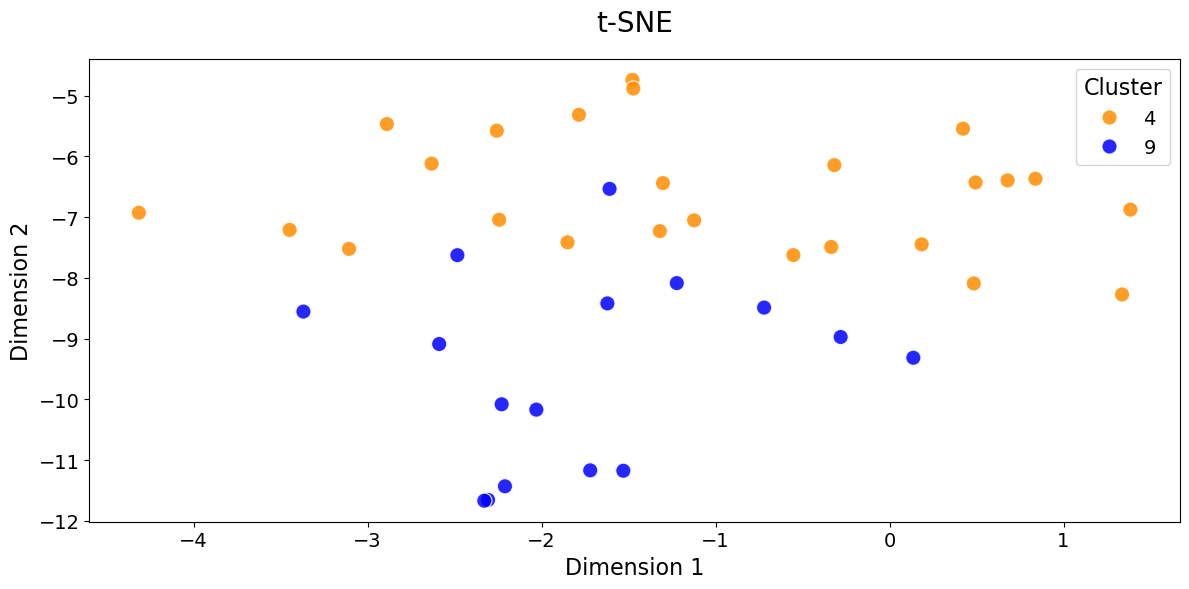

In [257]:
# Find actual populated clusters (largest two)
sizes = np.bincount(labels)
pop_idx = np.argsort(sizes)[-2:]  # Two largest
populated_clusters = pop_idx.tolist()
print(f"Auto-populated (largest): {populated_clusters} (sizes: {sizes[populated_clusters]})")

# Filter
populated_mask = np.isin(labels, populated_clusters)
populated_idx = np.where(populated_mask)[0]
D_pop = D_real[populated_idx]
labels_pop_str = [f"Cl{lab+1} ({len(populated_idx)} series)" for lab in labels[populated_idx]]
print(populated_idx)

if len(D_pop) == 0:
    print("ERROR: No populated series found. Check labels.")
else:
    print(f"Using clusters {populated_clusters} (real Cl{populated_clusters[0]+1}, Cl{populated_clusters[1]+1})")
    
    # M2DS
    scaler = RobustScaler()
    D_m2ds = scaler.fit_transform(D_pop)
    
    # t-SNE & plot
    tsne = TSNE(n_components=2, perplexity=min(20, len(D_pop)-1), random_state=10)
    embed_2d = tsne.fit_transform(D_m2ds)
    
    plt.figure(figsize=(12,6))
    
    # Swapped labels: '9' (blue), '4' (orange)
    cluster_labels = ['9' if labels[i] + 1 == 4 else '4' for i in populated_idx]
    
    # Colors: blue for 9, orange for 4
    palette = {'9': 'blue', '4': '#FF8C00'}
    sns.scatterplot(x=embed_2d[:,0], y=embed_2d[:,1], hue=cluster_labels, 
                    palette=palette, s=120, alpha=0.85)
    
    # Larger title (no bold)
    plt.title('t-SNE', fontsize=20, pad=20)
    
    # Axis labels
    plt.xlabel('Dimension 1', fontsize=16)
    plt.ylabel('Dimension 2', fontsize=16)
    
    # Larger legend
    plt.legend(title='Cluster', fontsize=14, title_fontsize=16)
    
    # Larger tick labels
    plt.tick_params(axis='both', labelsize=14)
    
    plt.tight_layout()
    plt.savefig('qaf_m2ds_tsne.png', dpi=300, bbox_inches='tight')
    plt.show()